# Treinando tratamento de dados da base Bolsa Família

### 1 - Faz a leitura de dois arquivos csv da base de dados oficial do Bolsa Família, dos meses de janeiro e fevereiro de 2025, utilizando a biblioteca do Pandas:

In [1]:
# import pandas as pd

# df_bolsa_jan = pd.read_csv("202501_NovoBolsaFamilia.csv", sep=';', encoding='latin1')
# df_bolsa_fev = pd.read_csv("202502_NovoBolsaFamilia.csv", sep=';', encoding='latin1') 


### 2 - Concatena os dois DataFrames um acima do outro (já que as colunas são iguais) para a análise de um só arquivo;

- O ".shape" mostra a quantidade de linhas e colunas da tabela;
- O ".tail" retorna as últimas linhas da tabela


In [2]:
# df_bolsa = pd.concat([df_bolsa_jan, df_bolsa_fev], ignore_index=True)

# df_bolsa.shape

# df_bolsa.tail(10)

### 3 - Converte o arquivo concatenado em ".parquet", para acelerar a leitura e o processamento dos dados ao longo do trabalho:

In [3]:
# df_bolsa.to_parquet("bolsafamilia_202501_202502.parquet", index=False)

### 4 - As células anteriores foram comentadas com "#" para não serem acionadas novamente na composição do código abaixo; 

- A seguir é feita a importação de todas as bibliotecas que serão utilizadas na sequência e a leitura do arquivo ".parquet" a paritr do uso da biblioteca do Polars:

In [21]:
import pandas as pd
import polars as pl
import unidecode
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

lf_bolsapl = pl.scan_parquet("bolsafamilia_202501_202502.parquet")

### 5 - Executa um LazyFrame (que executa os comandos primeiro para depois apresentar o resultado quando solicitado, poupando a memória do dispositivo), transformando-o em DataFrame.

- Em seguida apresenta a quantidade de linhas e colunas do .head (primeiras linhas) e do .tail (últimas linhas)

In [22]:
df_bolsapl = lf_bolsapl.collect()

{
    "Shape": df_bolsapl.shape,
    "Head": df_bolsapl.head(10),
    "Tail": df_bolsapl.tail(10)
}


{'Shape': (40810993, 9),
 'Head': shape: (10, 9)
 ┌────────────┬────────────┬─────┬────────────┬───┬────────────┬────────────┬───────────┬───────────┐
 │ MÊS COMPET ┆ MÊS        ┆ UF  ┆ CÓDIGO     ┆ … ┆ CPF        ┆ NIS        ┆ NOME FAVO ┆ VALOR     │
 │ ÊNCIA      ┆ REFERÊNCIA ┆ --- ┆ MUNICÍPIO  ┆   ┆ FAVORECIDO ┆ FAVORECIDO ┆ RECIDO    ┆ PARCELA   │
 │ ---        ┆ ---        ┆ str ┆ SIAFI      ┆   ┆ ---        ┆ ---        ┆ ---       ┆ ---       │
 │ i64        ┆ i64        ┆     ┆ ---        ┆   ┆ str        ┆ f64        ┆ str       ┆ str       │
 │            ┆            ┆     ┆ i64        ┆   ┆            ┆            ┆           ┆           │
 ╞════════════╪════════════╪═════╪════════════╪═══╪════════════╪════════════╪═══════════╪═══════════╡
 │ 202501     ┆ 202308     ┆ SP  ┆ 7071       ┆ … ┆ ***.085.10 ┆ 2.0644e10  ┆ FERNANDA  ┆ 650,00    │
 │            ┆            ┆     ┆            ┆   ┆ 6-**       ┆            ┆ RAMOS     ┆           │
 │            ┆            ┆     

### 6 - Apresenta o esquema de nomes das colunas e seus respectivos tipos de informação ou caracteres:

In [23]:
schema = df_bolsapl.collect_schema()
print(schema)

Schema({'MÊS COMPETÊNCIA': Int64, 'MÊS REFERÊNCIA': Int64, 'UF': String, 'CÓDIGO MUNICÍPIO SIAFI': Int64, 'NOME MUNICÍPIO': String, 'CPF FAVORECIDO': String, 'NIS FAVORECIDO': Float64, 'NOME FAVORECIDO': String, 'VALOR PARCELA': String})


### 7 - Renomeia o nome das colunas sem maiúsculas, espaços, acentos etc. E abrevia também para facilitar a escrita e busca:

In [ ]:
df_bolsapl = df_bolsapl.rename({
    "MÊS COMPETÊNCIA": "mes_comp",
    "MÊS REFERÊNCIA": "mes_ref",
    "UF": "uf",
    "CÓDIGO MUNICÍPIO SIAFI": "cod_municipio",
    "NOME MUNICÍPIO": "municipio",
    "CPF FAVORECIDO": "cpf",
    "NIS FAVORECIDO": "nis",
    "NOME FAVORECIDO": "favorecido",
    "VALOR PARCELA": "parcela"
})


### 8 - Converte de volta em Lazy para garantir que funcione corretamente na continuação do tratamendo de forma eficiente:

In [25]:
df_bolsapl = df_bolsapl.lazy() 

### 9 - Coluna do Valor da Parcela é convertida em Float64, a partir da troca da "," pelo ".", depois chama os 10 valores para visualização de como ficou:

In [26]:
df_bolsapl = df_bolsapl.with_columns([
    pl.col("parcela")
    .str.replace_all(",", ".")
    .cast(pl.Float64)
    .alias("parcela")
])

df_bolsapl.select("parcela").limit(10).collect()

parcela
f64
650.0
650.0
650.0
650.0
650.0
750.0
600.0
800.0
650.0


### 10 - Apresenta a quantidade de células nulas (em branco, sem valor) de cada coluna:

In [27]:
df_bolsapl.null_count().collect()


mes_comp,mes_ref,uf,cod_municipio,municipio,cpf,nis,favorecido,parcela
u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,7942467,725,0,0


### 11 - Faz uma comparação das colunas "mes_comp" e "mes_ref" para verificar se há redundâncias e retorna quantas existem:

In [ ]:
(
    df_bolsapl
        .filter(pl.col("mes_comp") != pl.col("mes_ref"))
        .collect()
        .height
)


193687

### 12 - Descarta a coluna "CPF" por ter muitos valores nulos e dispensáveis para o objetivo:

In [31]:
df_bolsapl = df_bolsapl.drop("cpf")


### 13 - Normaliza os nomes da coluna "municipio" retirando espaços e acentos e ajustando para não atrapalahar análises:

In [ ]:
df_bolsapl = df_bolsapl.with_columns([
    pl.col("municipio")
      .str.to_lowercase()
      .str.replace_all(r"[áàâã]", "a")
      .str.replace_all(r"[éêè]", "e")
      .str.replace_all(r"[íìî]", "i")
      .str.replace_all(r"[óòôõ]", "o")
      .str.replace_all(r"[úùû]", "u")
      .str.replace_all(r"[ç]", "c")
      .str.replace_all(r"\s+", "")  
      .alias("municipio")
])

### 14 - Garante que a coluna "nis" esteja no formato string e não float64:

In [ ]:
df_bolsapl = df_bolsapl.with_columns([
    pl.col("nis").cast(pl.Utf8).alias("nis")
])

### 15 - Verifica se existe algum valor não inteiro (que seja x.5, por exemplo) na coluna:

In [37]:
df_bolsapl.select(
    (pl.col("nis")
    .cast(pl.Float64) % 1 != 0)
    .sum()
    .alias("nis_nao_inteiros")
)


ColumnNotFoundError: "cpf" not found

Resolved plan until failure:

	---> FAILED HERE RESOLVING 'select' <---
 WITH_COLUMNS:
 [col("municipio").str.lowercase().str.replace(["[áàâã]", "a"]).str.replace(["[éêè]", "e"]).str.replace(["[íìî]", "i"]).str.replace(["[óòôõ]", "o"]).str.replace(["[úùû]", "u"]).str.replace(["[ç]", "c"]).str.replace(["\s+", ""])] 
  simple π 8/8 ["mes_comp", "mes_ref", "uf", ... 5 other columns]
     WITH_COLUMNS:
     [col("parcela").str.replace([",", "."]).strict_cast(Float64)] 
      DF ["mes_comp", "mes_ref", "uf", "cod_municipio", ...]; PROJECT */9 COLUMNS

In [ ]:
#conversão da coluna de valor para numero com . ao invés de ,

df_bolsapl_lazy = df_bolsapl.lazy().with_columns([
    pl.col("parcela")
    .cast(pl.Utf8)  # converte pra string antes do replace
    .str.replace_all(",", ".")
    .cast(pl.Float64)
    .alias("parcela")
])


In [ ]:
df_bolsapl = df_bolsapl.with_columns([
    pl.col("nis")
    .cast(pl.Utf8)
    .str.replace(r"\.0$", "")
    .alias("nis")
])

In [ ]:
#verificar se existem duplicatas no df:

# df_bolsapl_lazy = df_bolsapl.lazy()

# total_linhas = (
#     df_bolsapl_lazy
#     .select(pl.len().alias("n_rows"))   
#     .collect()["n_rows"][0]               
# )

# total_unicas = (
#     df_bolsapl_lazy
#     .unique()                             
#     .select(pl.len().alias("n_unique"))
#     .collect()["n_unique"][0]
# )

# num_duplicadas = total_linhas - total_unicas
# print(f"Linhas duplicadas: {num_duplicadas}")

In [ ]:
# df_bolsapl_lazy = df_bolsapl.lazy()

# colunas = df_bolsapl_lazy.collect_schema().names()

# duplicadas_lazy = (
#     df_bolsapl_lazy
#     .group_by(df_bolsapl.columns)
#     .agg(pl.len().alias("repeticoes"))
#     .filter(pl.col("repeticoes") > 1)
# )

In [ ]:
#ver todas as duplicatas:

# colunas = df_bolsapl_lazy.collect_schema().names()

# duplicadas_todas_lazy = (
#     df_bolsapl_lazy
#     .filter(pl.struct(colunas).is_duplicated())
#     .limit(1000)
# )

# duplicadas_todas = duplicadas_todas_lazy.collect()

# print(duplicadas_todas)


In [ ]:
#verificar tipo de dados em cada coluna:

schema = df_bolsapl_lazy.collect_schema()
print(schema)


Schema({'mes_comp': Int64, 'mes_ref': Int64, 'uf': String, 'cod_municipio': Int64, 'municipio': String, 'nis': String, 'favorecido': String, 'parcela': Float64})


In [ ]:
#converter 'cod muicipio' para string:

df_bolsapl_lazy = df_bolsapl_lazy.with_columns(
    pl.col("cod_municipio").cast(pl.Utf8)
)


In [ ]:
#converter datas para formato date e meses abreviados em nome:

# Converter coluna para string
df_bolsapl_lazy = df_bolsapl_lazy.with_columns(
    pl.col("mes_competencia").cast(pl.Utf8)
)

# Adicionar '01' ao final para representar o primeiro dia do mês
df_bolsapl_lazy = df_bolsapl_lazy.with_columns(
    (pl.col("mes_competencia") + "01").alias("mes_competencia_str")
)

# Converter para tipo date (formato ano+mês+dia)
df_bolsapl_lazy = df_bolsapl_lazy.with_columns(
    pl.col("mes_competencia_str").str.strptime(pl.Date, format="%Y%m%d")
)

# Criar nova coluna com mês e ano no formato 'jan 2025'
df_bolsapl_lazy = df_bolsapl_lazy.with_columns(
    pl.col("mes_competencia_str").dt.strftime("%b %Y").alias("mes_competencia_nome")
)


In [ ]:
#agora o mesmo com 'mes_referencia':

# Converter coluna para string
df_bolsapl_lazy = df_bolsapl_lazy.with_columns([
    pl.col("mes_referencia").cast(pl.Utf8),
    (pl.col("mes_referencia") + "01").alias("mes_referencia_str"),
    pl.col("mes_referencia_str").str.strptime(pl.Date, format="%Y%m%d"),
    pl.col("mes_referencia_str").dt.strftime("%b %Y").alias("mes_referencia_nome")
])

In [ ]:
# Converter string para float

df_bolsapl_lazy = df_bolsapl_lazy.with_columns(
    pl.col("valor_parcela").cast(pl.Float64).round(2).alias("valor_parcela")
)


In [ ]:
df_bolsapl_lazy = df_bolsapl.lazy()

amostra = (
    df_bolsapl_lazy
    .select([
        "nis",
        "favorecido",
        "parcela",
        "cod_municipio",
        "uf",
        "municipio",
        "mes_comp",
        "mes_ref"
    ])
    .limit(10)
    .collect()
)

print(amostra)


shape: (10, 8)
┌─────────────┬───────────────┬─────────┬───────────────┬─────┬───────────────┬──────────┬─────────┐
│ nis         ┆ favorecido    ┆ parcela ┆ cod_municipio ┆ uf  ┆ municipio     ┆ mes_comp ┆ mes_ref │
│ ---         ┆ ---           ┆ ---     ┆ ---           ┆ --- ┆ ---           ┆ ---      ┆ ---     │
│ str         ┆ str           ┆ f64     ┆ i64           ┆ str ┆ str           ┆ i64      ┆ i64     │
╞═════════════╪═══════════════╪═════════╪═══════════════╪═════╪═══════════════╪══════════╪═════════╡
│ 20643890445 ┆ FERNANDA      ┆ 650.0   ┆ 7071          ┆ SP  ┆ santos        ┆ 202501   ┆ 202308  │
│             ┆ RAMOS         ┆         ┆               ┆     ┆               ┆          ┆         │
│             ┆ TEIXEIRA      ┆         ┆               ┆     ┆               ┆          ┆         │
│ 20643890445 ┆ FERNANDA      ┆ 650.0   ┆ 7071          ┆ SP  ┆ santos        ┆ 202501   ┆ 202309  │
│             ┆ RAMOS         ┆         ┆               ┆     ┆             

In [ ]:
#tratamento de outliers na coluna de valor:

q_vals = (
    df_bolsapl_lazy
    .select([
        pl.col("parcela").quantile(0.25).alias("q1"),
        pl.col("parcela").quantile(0.75).alias("q3")
    ])
    .collect()
)

q1 = q_vals["q1"][0]
q3 = q_vals["q3"][0]
iqr = q3 - q1
limite_inferior  = q1 - 1.5 * iqr
limite_superior  = q3 + 1.5 * iqr

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Limite inferior:",  limite_inferior)
print("Limite superior:",  limite_superior)

outliers_lazy = df_bolsapl_lazy.filter(
    (pl.col("parcela") < limite_inferior) |
    (pl.col("parcela") > limite_superior)
)

sem_outliers_lazy = df_bolsapl_lazy.filter(
    (pl.col("parcela") >= limite_inferior) &
    (pl.col("parcela") <= limite_superior)
)

print("Outliers encontrados:")
print(
    outliers_lazy
    .select([
        "parcela", "favorecido", "municipio",
        "uf", "mes_comp", "mes_ref"
    ])
    .limit(10)
    .collect()
)

print("\nSem outliers:")
print(
    sem_outliers_lazy
    .select([
        "parcela", "nis", "municipio",
        "uf", "mes_comp", "mes_ref"
    ])
    .limit(10)
    .collect()
)


Q1: 600.0
Q3: 750.0
IQR: 150.0
Limite inferior: 375.0
Limite superior: 975.0
Outliers encontrados:
shape: (10, 6)
┌─────────┬─────────────────────────────────┬───────────────────┬─────┬──────────┬─────────┐
│ parcela ┆ favorecido                      ┆ municipio         ┆ uf  ┆ mes_comp ┆ mes_ref │
│ ---     ┆ ---                             ┆ ---               ┆ --- ┆ ---      ┆ ---     │
│ f64     ┆ str                             ┆ str               ┆ str ┆ i64      ┆ i64     │
╞═════════╪═════════════════════════════════╪═══════════════════╪═════╪══════════╪═════════╡
│ 1010.0  ┆ ERICA CRISTINA RIBEIRO DA SILV… ┆ pirassununga      ┆ SP  ┆ 202501   ┆ 202401  │
│ 1010.0  ┆ ERICA CRISTINA RIBEIRO DA SILV… ┆ pirassununga      ┆ SP  ┆ 202501   ┆ 202402  │
│ 1010.0  ┆ ERICA CRISTINA RIBEIRO DA SILV… ┆ pirassununga      ┆ SP  ┆ 202501   ┆ 202403  │
│ 1102.0  ┆ MARCELA DA SILVA RAMALHO        ┆ itanhaem          ┆ SP  ┆ 202501   ┆ 202404  │
│ 1010.0  ┆ ERICA CRISTINA RIBEIRO DA SILV… ┆ pir

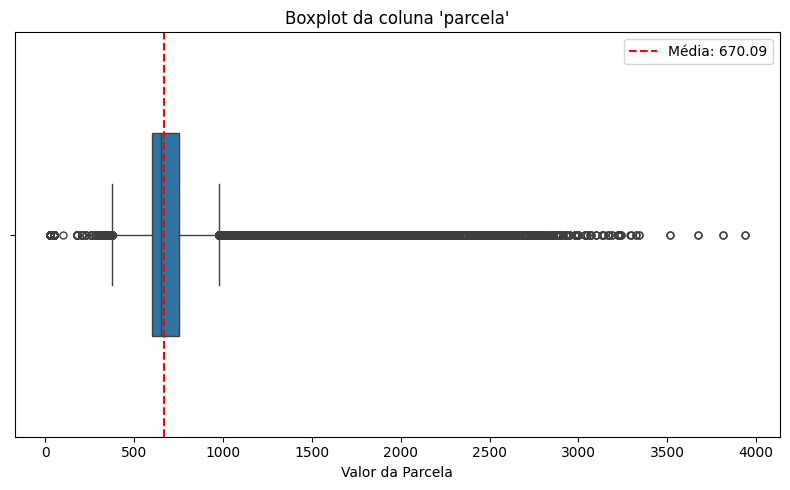

In [ ]:
#criando boxplot para mostrar outliers e outros valores:

# df_plot = df_bolsapl_lazy.select(["parcela"]).collect().to_pandas()

# plt.figure(figsize=(8,5))
# sns.boxplot(data=df_plot, x="parcela", width=0.5, fliersize=5)

# media = df_plot["parcela"].mean()
# plt.axvline(media, color='red', linestyle='--', label=f"Média: {media:.2f}")

# plt.title("Boxplot da coluna 'parcela'")
# plt.legend()
# plt.xlabel("Valor da Parcela")
# plt.tight_layout()
# plt.show()

In [ ]:
#verifica os 10 maiores valores da coluna:

df_bolsapl_lazy.sort("parcela", descending=True).limit(10).collect()


mes_comp,mes_ref,uf,cod_municipio,municipio,nis,favorecido,parcela
i64,i64,str,i64,str,str,str,f64
202501,202501,"""AM""",241,"""itacoatiara""","""21218468159""","""EVERTON DA SILVA DE MELO""",3938.0
202502,202502,"""AM""",241,"""itacoatiara""","""21218468159""","""EVERTON DA SILVA DE MELO""",3938.0
202501,202501,"""AM""",207,"""autazes""","""16449789671""","""LENITA CORREIA DE MENEZES""",3814.0
202502,202502,"""AM""",207,"""autazes""","""16449789671""","""LENITA CORREIA DE MENEZES""",3814.0
202501,202501,"""GO""",9571,"""rioverde""","""21217665503""","""BERENICE REDZE""",3674.0
202502,202502,"""GO""",9571,"""rioverde""","""21217665503""","""BERENICE REDZE""",3674.0
202501,202501,"""MT""",97,"""querencia""","""23653255100""","""JOAO DE DEUS SIRVO""",3514.0
202502,202502,"""MT""",97,"""querencia""","""23653255100""","""JOAO DE DEUS SIRVO""",3514.0
202501,202501,"""GO""",9445,"""luziania""","""16580299712""","""THAYNARA FERREIRA VELOSO""",3338.0


In [ ]:
#quantidade de outliers por estado:

outliers = df_bolsapl_lazy.filter(
    (pl.col("parcela") > limite_superior) | (pl.col("parcela") < limite_inferior)
)

print(
    outliers.group_by("uf").agg(
        pl.len().alias("quantidade_outliers")
    ).sort("quantidade_outliers", descending=True).collect()
)

shape: (27, 2)
┌─────┬─────────────────────┐
│ uf  ┆ quantidade_outliers │
│ --- ┆ ---                 │
│ str ┆ u32                 │
╞═════╪═════════════════════╡
│ SP  ┆ 726800              │
│ BA  ┆ 518020              │
│ MG  ┆ 460539              │
│ RJ  ┆ 377139              │
│ PA  ┆ 342673              │
│ …   ┆ …                   │
│ TO  ┆ 52283               │
│ AC  ┆ 42930               │
│ RO  ┆ 38900               │
│ AP  ┆ 34675               │
│ RR  ┆ 30705               │
└─────┴─────────────────────┘


In [ ]:
# somatório de valor por beneficiário:

benef_totais_lazy = (
    df_bolsapl_lazy
    .group_by(["favorecido", "uf", "municipio"])
    .agg(
        pl.col("parcela").sum().alias("total_recebido")
    )
    .sort("total_recebido", descending=True)  
)

benef_totais_top20 = benef_totais_lazy.head().collect()

benef_totais_top20


favorecido,uf,municipio,total_recebido
str,str,str,f64
"""MARIA APARECIDA DA SILVA""","""SP""","""saopaulo""",444601.0
"""MARIA JOSE DA SILVA""","""SP""","""saopaulo""",381595.0
"""MARIA JOSE DA SILVA""","""PE""","""jaboataodosguararapes""",361988.0
"""MARIA JOSE DA SILVA""","""PE""","""caruaru""",354864.0
"""MARIA JOSE DA SILVA""","""PE""","""recife""",345583.0


In [ ]:
benef_totais_lazy = (
    df_bolsapl.lazy()
    .group_by(["favorecido", "uf", "municipio", "mes_ref", "mes_comp"])
    .agg(
        pl.col("parcela").sum().alias("total_recebido")
    )
    .sort("total_recebido", descending=True)
)

# Pegar os 10 primeiros (ainda em Lazy)
benef_totais_top10_lazy = benef_totais_lazy.limit(10)


In [ ]:
#comparar estados entre si em total e média de valor:

# Agrupamento por estado (uf), com soma e média
df_estados_lazy = (
    df_bolsapl_lazy
    .group_by("uf")
    .agg([
        pl.col("parcela").sum().alias("total_estado"),
        pl.col("parcela").mean().alias("media_estado")
    ])
    .sort("media_estado", descending=True)
)

# Formatação do total em milhões


# Mostrar os 10 primeiros
df_estados_lazy.head().limit(10).collect()


uf,total_estado,media_estado
str,f64,f64
"""RR""",1.16930357e8,737.279753
"""AM""",9.31367231e8,727.248844
"""AC""",1.88140636e8,718.774397
"""AP""",1.74154882e8,717.486918
"""PA""",1.8648e9,697.50517


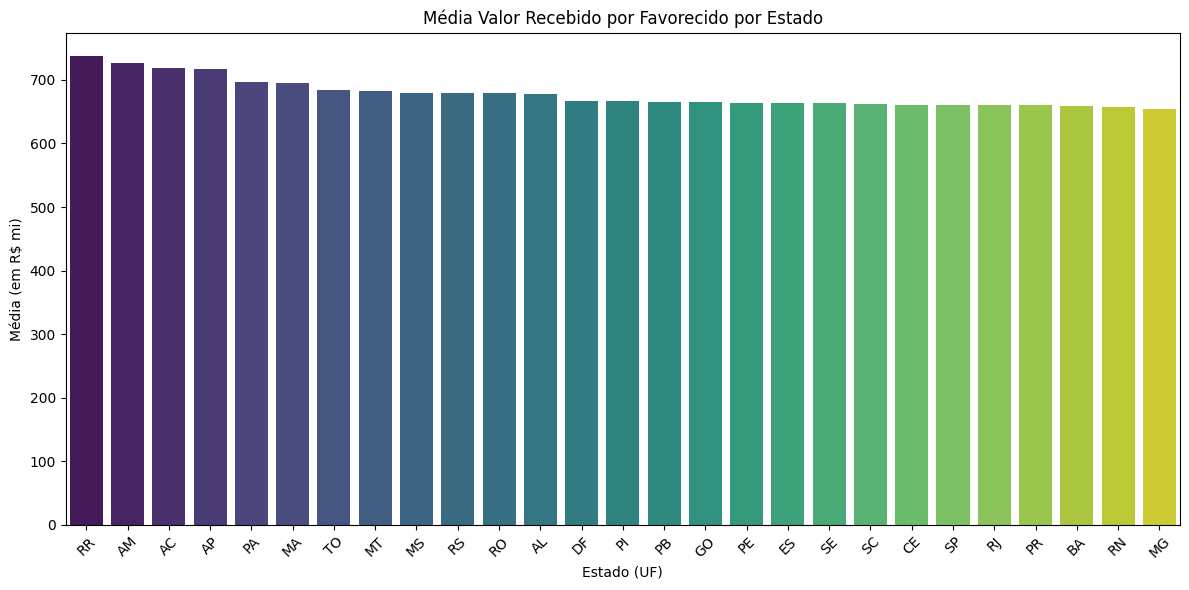

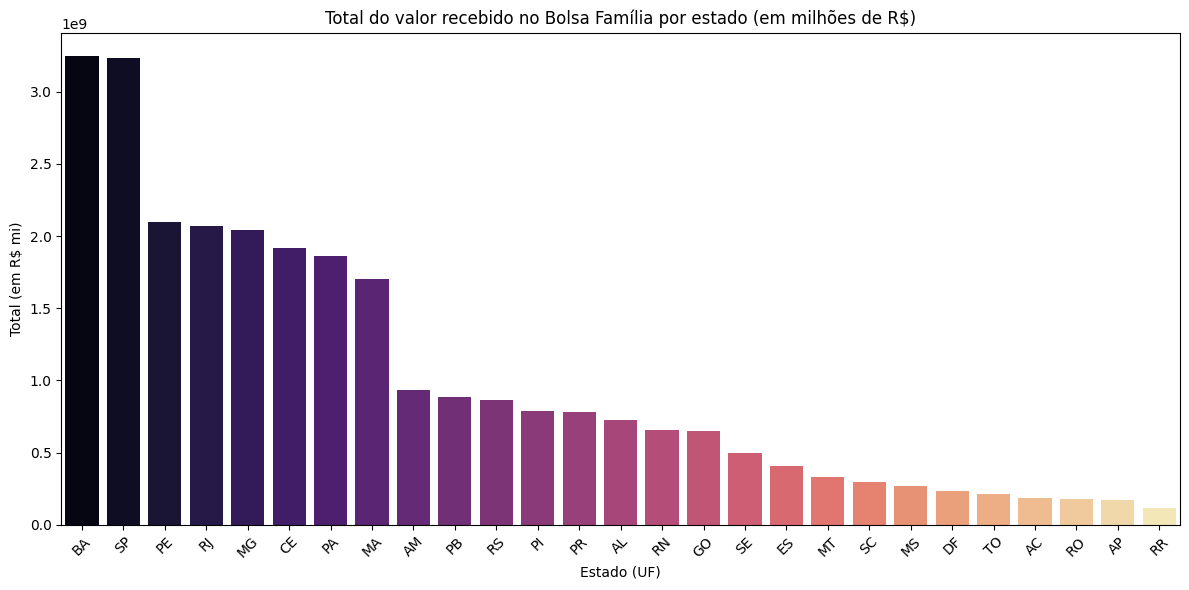

In [ ]:
df_total = (
    df_estados_lazy
    .sort("total_estado", descending=True)
    .select(["uf", "total_estado"])
    .collect()
)

# Para o gráfico da média por estado
df_media = (
    df_estados_lazy
    .sort("media_estado", descending=True)
    .select(["uf", "media_estado"])
    .collect()
)

plt.figure(figsize=(12,6))
sns.barplot(
    data=df_media.to_pandas(),
    x="uf",
    y="media_estado",
    hue="uf",
    palette="viridis",
    legend=False
)
plt.title("Média Valor Recebido por Favorecido por Estado")
plt.xlabel("Estado (UF)")
plt.ylabel("Média (em R$ mi)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Para o gráfico do total por estado (agora total_estado já é float)
df_total = (
    df_estados_lazy
    .sort("total_estado", descending=True)
    .select(["uf", "total_estado"])
    .collect()
)

plt.figure(figsize=(12,6))
sns.barplot(
    data=df_total.to_pandas(),
    x="uf",
    y="total_estado",
    hue="uf",
    palette="magma",
    legend=False
)
plt.title("Total do valor recebido no Bolsa Família por estado (em milhões de R$)")
plt.xlabel("Estado (UF)")
plt.ylabel("Total (em R$ mi)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

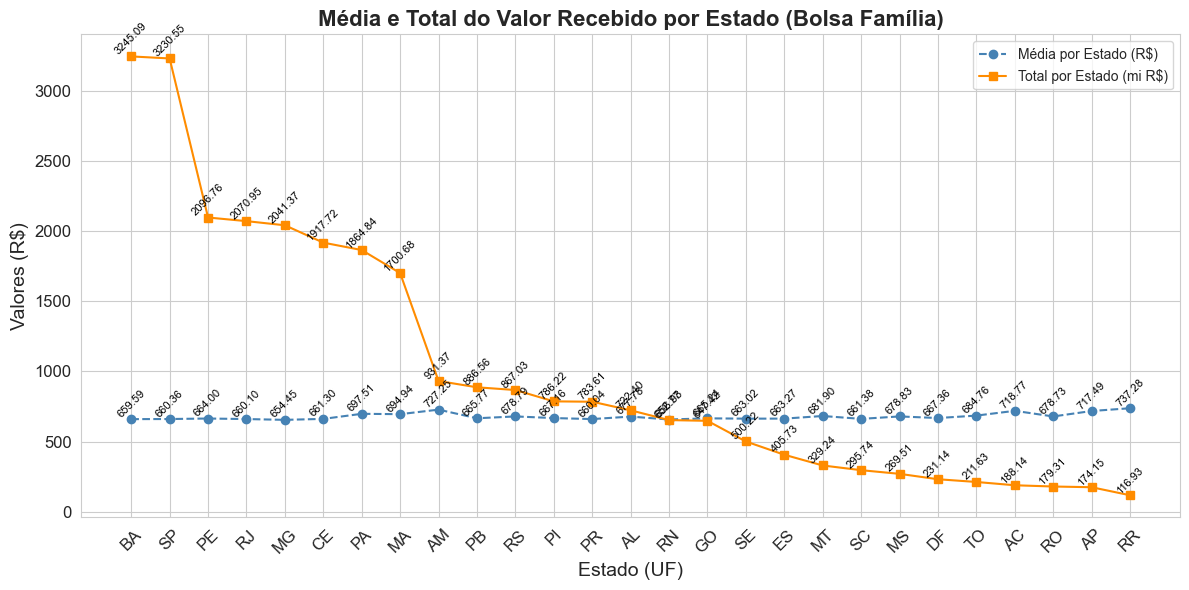

In [ ]:
# Ordena pela média em ordem decrescente e converte para pandas
sns.set_style("whitegrid")

df_plot = (
    df_estados_lazy
    .select(["uf", "media_estado", "total_estado"])
    .sort("total_estado", descending=True)
    .collect()
    .to_pandas()
)

plt.figure(figsize=(12, 6))

plt.plot(df_plot["uf"], df_plot["media_estado"], marker='o', linestyle='--', label="Média por Estado (R$)", color="steelblue")
plt.plot(df_plot["uf"], df_plot["total_estado"] / 1_000_000, marker='s', linestyle='-', label="Total por Estado (mi R$)", color="darkorange")

# Adiciona os valores da média acima dos pontos em preto
for i, valor in enumerate(df_plot["media_estado"]):
    plt.text(i, valor + 0.5, f"{valor:.2f}", ha='center', va='bottom', color='black', fontsize=8, rotation=45)

# Adiciona os valores do total (dividido por milhão) acima dos pontos em preto
for i, valor in enumerate(df_plot["total_estado"] / 1_000_000):
    plt.text(i, valor + 0.5, f"{valor:.2f}", ha='center', va='bottom', color='black', fontsize=8, rotation=45)


plt.title("Média e Total do Valor Recebido por Estado (Bolsa Família)", fontsize=16, fontweight='bold')
plt.xlabel("Estado (UF)", fontsize=14)
plt.ylabel("Valores (R$)", fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("grafico_valores_estado.png", dpi=300)
plt.show()

In [ ]:
# mesmo gráfico usando interatividade do plotly:

df_plot["total_estado_milhoes"] = df_plot["total_estado"] / 1_000_000

fig = px.line(
    df_plot,
    x="uf",
    y=["media_estado", "total_estado_milhoes"],
    markers=True,
    labels={
        "value": "Valor (R$)",
        "variable": "Tipo de Valor",
        "uf": "Estado (UF)"
    },
    title="Média e Total do Valor Recebido por Estado (Bolsa Família)"
)

fig.update_traces(textposition="top center")
fig.update_layout(
    xaxis_title="Estado (UF)",
    yaxis_title="Valores",
    legend_title_text="",
    hovermode="x unified",
    template="plotly_white"
)

fig.show()


In [ ]:
df_bolsapl_lazy.collect().write_parquet("bolsapl_tratado.csv")
